# E-Commerce Sales Analysis

## Week 4 – Data Visualization & Complete Data Analysis Project

### Project Overview

This project performs an end-to-end analysis of e-commerce sales data using Python.

The project covers:

- Data loading
- Data validation
- Data cleaning
- Exploratory Data Analysis (EDA)
- Sales analysis
- Product analysis
- Regional analysis
- Monthly trend analysis
- Data visualization
- Error handling
- Testing and verification
- Business insights
- Professional documentation

### Objective

The primary objective of this project is to analyze e-commerce sales data and identify meaningful patterns related to products, sales, quantities, regions, and time.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Display floating-point values with 2 decimal places
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt


In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Display floating-point values with 2 decimal places
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


Load Dataset

In [4]:
#Load the sales dataset

file_path="sales_data (1).csv"

try:
    df=pd.read_csv(file_path)
    print("Dataset Loaded successfully")

except FileNotFoundError:
    print("ERROR:Dataset file was not found")

except Exception as e:
    print(f"Error:unable to load dataset Details: {e}")

Dataset Loaded successfully


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (100, 7)


In [6]:
print("\nNumber of Rows:", df.shape[0])


Number of Rows: 100


In [7]:
print("Number of Columns:", df.shape[1])

Number of Columns: 7


In [8]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']


In [9]:
df.head(10)

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
5,2024-01-06,Laptop,7,40420,CUST006,South,282940
6,2024-01-07,Laptop,9,40430,CUST007,South,363870
7,2024-01-08,Laptop,7,7262,CUST008,West,50834
8,2024-01-09,Tablet,3,32791,CUST009,North,98373
9,2024-01-10,Laptop,4,45023,CUST010,West,180092


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [11]:
# Generate descriptive statistics for numerical columns

df.describe()

,Quantity,Price,Total_Sales
count,100.00,100.00,100.00
mean,4.78,"25,808.51","123,650.48"
std,2.59,"13,917.63","100,161.09"
min,1.00,"1,308.00","6,540.00"
25%,2.75,"14,965.25","39,517.50"
50%,5.00,"24,192.00","97,955.50"
75%,7.00,"38,682.25","175,792.50"
max,9.00,"49,930.00","373,932.00"


In [12]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing Values by Column:")
print(missing_values)

Missing Values by Column:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [13]:
# Verify whether the dataset contains any missing values

if df.isnull().sum().sum() == 0:
    print("PASS: No missing values found.")
else:
    print("WARNING: Missing values detected.")
    print(df.isnull().sum())

PASS: No missing values found.


In [14]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("PASS: No duplicate records found.")
else:
    print("WARNING: Duplicate records detected.")

Number of duplicate rows: 0
PASS: No duplicate records found.


In [15]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Date column converted successfully.")
print("\nData type of Date column:", df["Date"].dtype)

Date column converted successfully.

Data type of Date column: datetime64[ns]


In [16]:
# Validate Date conversion

invalid_dates = df["Date"].isna().sum()

print("Invalid dates after conversion:", invalid_dates)

if invalid_dates == 0:
    print("PASS: All dates are valid.")
else:
    print("FAIL: Invalid dates detected.")

Invalid dates after conversion: 0
PASS: All dates are valid.


In [17]:
# Validate numerical columns

numeric_columns = ["Quantity", "Price", "Total_Sales"]

for column in numeric_columns:
    invalid_values = pd.to_numeric(df[column], errors="coerce").isna().sum()
    
    print(f"{column}: {invalid_values} invalid numeric values")
    
    if invalid_values == 0:
        print(f"PASS: {column} contains valid numeric values.")
    else:
        print(f"FAIL: {column} contains invalid values.")

Quantity: 0 invalid numeric values
PASS: Quantity contains valid numeric values.
Price: 0 invalid numeric values
PASS: Price contains valid numeric values.
Total_Sales: 0 invalid numeric values
PASS: Total_Sales contains valid numeric values.


In [18]:
# Check for negative values in important numeric columns

for column in numeric_columns:
    
    negative_count = (df[column] < 0).sum()
    
    print(f"{column}: {negative_count} negative values")
    
    if negative_count == 0:
        print(f"PASS: No negative values found in {column}.")
    else:
        print(f"WARNING: Negative values found in {column}.")

Quantity: 0 negative values
PASS: No negative values found in Quantity.
Price: 0 negative values
PASS: No negative values found in Price.
Total_Sales: 0 negative values
PASS: No negative values found in Total_Sales.


In [19]:
df.describe()

,Date,Quantity,Price,Total_Sales
count,100,100.00,100.00,100.00
mean,2024-02-19 12:00:00,4.78,"25,808.51","123,650.48"
min,2024-01-01 00:00:00,1.00,"1,308.00","6,540.00"
25%,2024-01-25 18:00:00,2.75,"14,965.25","39,517.50"
50%,2024-02-19 12:00:00,5.00,"24,192.00","97,955.50"
75%,2024-03-15 06:00:00,7.00,"38,682.25","175,792.50"
max,2024-04-09 00:00:00,9.00,"49,930.00","373,932.00"
std,NaN,2.59,"13,917.63","100,161.09"


In [20]:
# Define required columns

required_columns = [
    "Date",
    "Product",
    "Quantity",
    "Price",
    "Customer_ID",
    "Region",
    "Total_Sales"
]

# Check whether all required columns exist

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if len(missing_columns) == 0:
    print("PASS: All required columns are present.")
else:
    print("FAIL: Missing required columns:")
    print(missing_columns)

PASS: All required columns are present.


In [21]:
# Check for blank product names and regions

blank_products = df["Product"].astype(str).str.strip().eq("").sum()
blank_regions = df["Region"].astype(str).str.strip().eq("").sum()

print("Blank product names:", blank_products)
print("Blank regions:", blank_regions)

if blank_products == 0 and blank_regions == 0:
    print("\nPASS: Product and Region fields are complete.")
else:
    print("\nWARNING: Blank Product or Region values detected.")

Blank product names: 0
Blank regions: 0

PASS: Product and Region fields are complete.


In [ ]:
# Create a validation summary
validation_summary = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Missing Values": int(df.isnull().sum().sum()),
    "Duplicate Rows": int(df.duplicated().sum()),
    "Invalid Dates": int(df["Date"].isna().sum()),
    "Negative Quantities": int((df["Quantity"] < 0).sum()),
    "Negative Prices": int((df["Price"] < 0).sum()),
    "Negative Sales": int((df["Total_Sales"] < 0).sum())
}

validation_df = pd.DataFrame(
    validation_summary.items(),
    columns=["Validation Check", "Result"]
)

validation_df

,Validation Check,Result
0,Rows,100
1,Columns,7
2,Missing Values,0
3,Duplicate Rows,0
4,Invalid Dates,0
5,Negative Quantities,0
6,Negative Prices,0
7,Negative Sales,0


# 6. Data Cleaning

After validation, the dataset is cleaned and standardized for analysis.

The cleaning process includes:

- Standardizing text fields
- Ensuring correct data types
- Removing accidental whitespace
- Checking for records requiring removal
- Creating a clean dataset for analysis

The original dataset will not be overwritten.

In [23]:
# Create a separate copy for cleaning

clean_df = df.copy()

print("Clean dataset created successfully.")

Clean dataset created successfully.


In [24]:
# Remove unnecessary spaces from text columns

text_columns = ["Product", "Customer_ID", "Region"]

for column in text_columns:
    clean_df[column] = clean_df[column].astype(str).str.strip()

print("Text fields standardized successfully.")

Text fields standardized successfully.


In [25]:
# Ensure numeric columns have the correct data type

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

print("Numeric columns standardized successfully.")

Numeric columns standardized successfully.


# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the main characteristics and patterns in the cleaned dataset.

In this section, we will analyze:

- Total revenue
- Total quantity sold
- Average sales per transaction
- Average product price
- Number of unique products
- Number of unique customers
- Number of regions
- Minimum and maximum sales

In [ ]:
# Calculate key business metrics
total_revenue = clean_df["Total_Sales"].sum()
total_quantity = clean_df["Quantity"].sum()
average_sales = clean_df["Total_Sales"].mean()
average_price = clean_df["Price"].mean()

unique_products = clean_df["Product"].nunique()
unique_customers = clean_df["Customer_ID"].nunique()
unique_regions = clean_df["Region"].nunique()

minimum_sale = clean_df["Total_Sales"].min()
maximum_sale = clean_df["Total_Sales"].max()

print("E-COMMERCE SALES SUMMARY")
print("-" * 30)

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Sales per Transaction: ₹{average_sales:,.2f}")
print(f"Average Product Price: ₹{average_price:,.2f}")
print(f"Unique Products: {unique_products}")
print(f"Unique Customers: {unique_customers}")
print(f"Number of Regions: {unique_regions}")
print(f"Minimum Transaction Sales: ₹{minimum_sale:,.2f}")
print(f"Maximum Transaction Sales: ₹{maximum_sale:,.2f}")

E-COMMERCE SALES SUMMARY
------------------------------
Total Revenue: ₹12,365,048.00
Total Quantity Sold: 478
Average Sales per Transaction: ₹123,650.48
Average Product Price: ₹25,808.51
Unique Products: 5
Unique Customers: 100
Number of Regions: 4
Minimum Transaction Sales: ₹6,540.00
Maximum Transaction Sales: ₹373,932.00


## 7.1 Product Performance Analysis

This section identifies which products generate the highest sales and which products have the highest quantities sold.

In [27]:
# Calculate sales and quantity by product

product_analysis = clean_df.groupby("Product").agg(
    Total_Revenue=("Total_Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Average_Price=("Price", "mean")
).sort_values(
    "Total_Revenue",
    ascending=False
)

product_analysis

,Total_Revenue,Total_Quantity,Average_Price
Product,,,
Laptop,3889210,136,"27,651.50"
Tablet,2884340,127,"24,177.23"
Phone,2859394,101,"27,379.00"
Headphones,1384033,48,"28,692.13"
Monitor,1348071,66,"20,709.67"


In [28]:
# Identify the highest-revenue product

best_product = product_analysis["Total_Revenue"].idxmax()
best_product_revenue = product_analysis["Total_Revenue"].max()

print("Best-performing product:", best_product)
print(f"Revenue generated: ₹{best_product_revenue:,.2f}")

Best-performing product: Laptop
Revenue generated: ₹3,889,210.00


## 7.2 Regional Sales Analysis

This section compares sales performance across different regions.

In [29]:
# Calculate sales by region

regional_analysis = clean_df.groupby("Region").agg(
    Total_Revenue=("Total_Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Transactions=("Total_Sales", "count")
).sort_values(
    "Total_Revenue",
    ascending=False
)

regional_analysis

,Total_Revenue,Total_Quantity,Number_of_Transactions
Region,,,
North,3983635,147,28
South,3737852,143,27
East,2519639,94,19
West,2123922,94,26


In [30]:
# Identify the highest-revenue region

best_region = regional_analysis["Total_Revenue"].idxmax()
best_region_revenue = regional_analysis["Total_Revenue"].max()

print("Best-performing region:", best_region)
print(f"Revenue generated: ₹{best_region_revenue:,.2f}")

Best-performing region: North
Revenue generated: ₹3,983,635.00


## 7.3 Monthly Sales Analysis

Monthly sales analysis helps identify trends and changes in revenue over time.

In [31]:
# Create a Month column from the Date column

clean_df["Month"] = clean_df["Date"].dt.to_period("M").astype(str)

# Calculate monthly revenue

monthly_sales = clean_df.groupby("Month")["Total_Sales"].sum()

monthly_sales

Month
2024-01    4120524
2024-02    2656050
2024-03    4485006
2024-04    1103468
Name: Total_Sales, dtype: int64

In [32]:
clean_df["Month"]

0     2024-01
1     2024-01
2     2024-01
3     2024-01
4     2024-01
       ...   
95    2024-04
96    2024-04
97    2024-04
98    2024-04
99    2024-04
Name: Month, Length: 100, dtype: object

In [33]:
# Identify the month with the highest revenue

best_month = monthly_sales.idxmax()
best_month_revenue = monthly_sales.max()

print("Highest-revenue month:", best_month)
print(f"Revenue generated: ₹{best_month_revenue:,.2f}")

Highest-revenue month: 2024-03
Revenue generated: ₹4,485,006.00


# 8. Data Visualization

Data visualization helps communicate patterns and trends clearly.

This project uses three visualization types:

1. Bar Chart – Compare revenue across products
2. Line Chart – Analyze monthly revenue trends
3. Pie Chart – Show regional revenue contribution

All charts will be saved as PNG files in the `visualizations` folder.

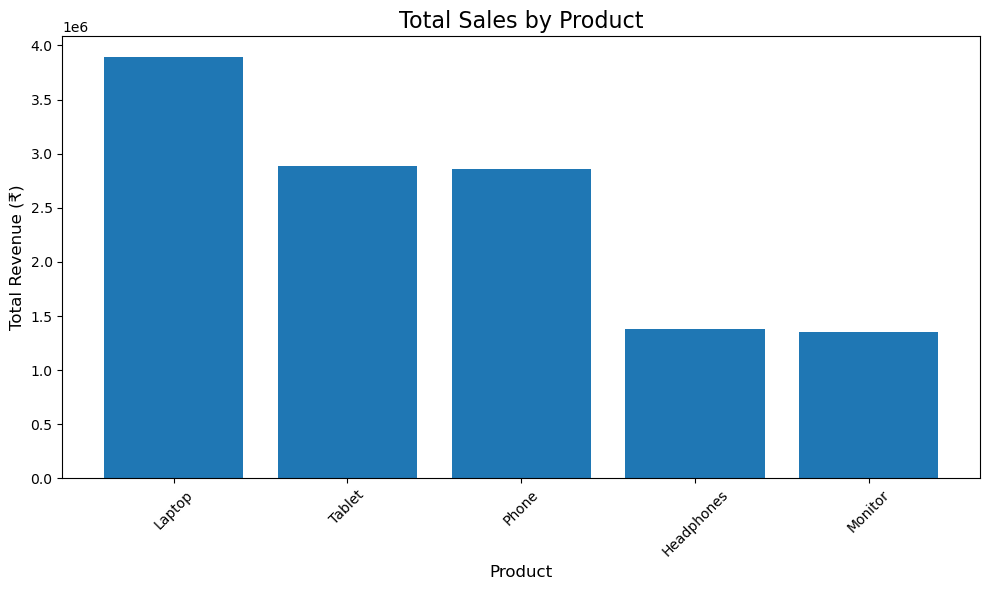

In [34]:
# Create the visualizations folder if it does not exist

import os

os.makedirs("visualizations", exist_ok=True)

# Create a bar chart showing revenue by product

plt.figure(figsize=(10, 6))

plt.bar(
    product_analysis.index,
    product_analysis["Total_Revenue"]
)

plt.title("Total Sales by Product", fontsize=16)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()

# Save the chart
plt.savefig(
    "visualizations/sales_by_product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
plt.savefig("visualizations/sales_by_product.png")

<Figure size 640x480 with 0 Axes>

In [36]:
os.makedirs("visualizations", exist_ok=True)

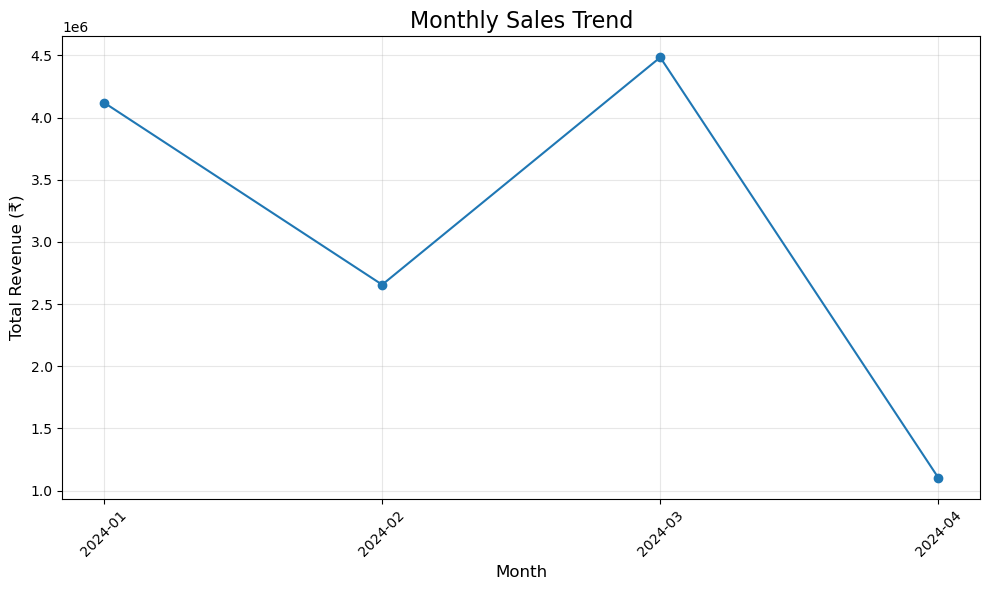

In [37]:
# Create the visualizations folder if it does not exist

import os

os.makedirs("visualizations", exist_ok=True)

# Create a line chart for monthly sales

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save the chart
plt.savefig(
    "visualizations/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

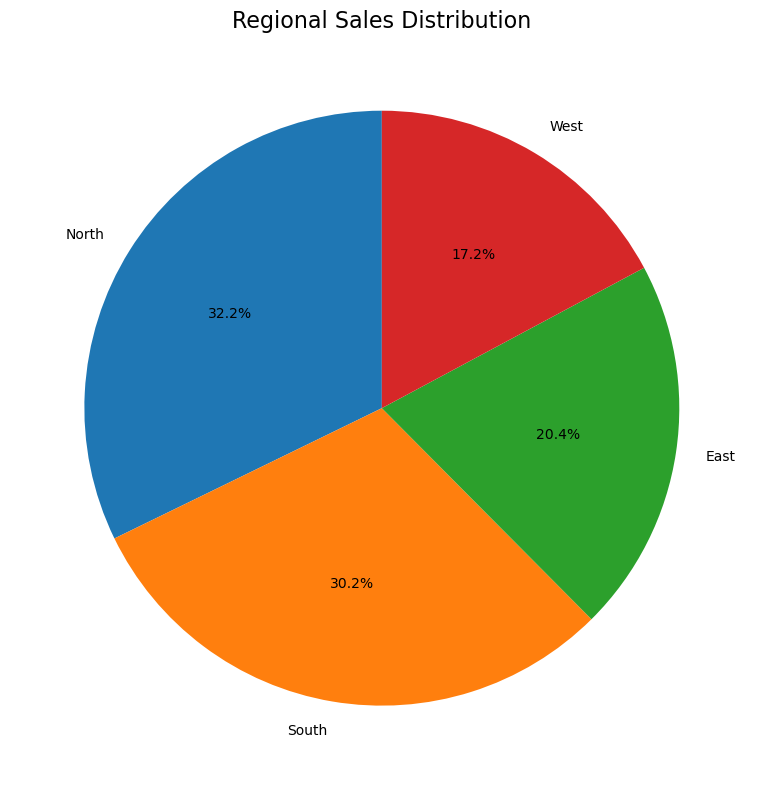

In [38]:
# Make sure the visualizations folder exists

import os

os.makedirs("visualizations", exist_ok=True)

# Create a pie chart showing regional revenue distribution

plt.figure(figsize=(8, 8))

plt.pie(
    regional_analysis["Total_Revenue"],
    labels=regional_analysis.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Regional Sales Distribution", fontsize=16)

plt.tight_layout()

# Save the chart
plt.savefig(
    "visualizations/regional_sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Verify that all visualization files were created

visualization_files = [
    "visualizations/sales_by_product.png",
    "visualizations/monthly_sales_trend.png",
    "visualizations/regional_sales_distribution.png"
]

for file in visualization_files:
    if os.path.exists(file):
        print("PASS:", file)
    else:
        print("FAIL:", file)

PASS: visualizations/sales_by_product.png
PASS: visualizations/monthly_sales_trend.png
PASS: visualizations/regional_sales_distribution.png


# 9. Business Insights

The analysis and visualizations are used to identify meaningful business patterns.

The key areas examined are:

- Overall sales performance
- Product performance
- Regional performance
- Monthly sales trends
- Potential areas for improvement

In [40]:
# Display overall business performance

print("OVERALL BUSINESS PERFORMANCE")
print("-" * 35)

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Transaction Sales: ₹{average_sales:,.2f}")
print(f"Number of Products: {unique_products}")
print(f"Number of Customers: {unique_customers}")
print(f"Number of Regions: {unique_regions}")

OVERALL BUSINESS PERFORMANCE
-----------------------------------
Total Revenue: ₹12,365,048.00
Total Quantity Sold: 478
Average Transaction Sales: ₹123,650.48
Number of Products: 5
Number of Customers: 100
Number of Regions: 4


In [41]:
# Display product performance

print("PRODUCT PERFORMANCE")
print("-" * 30)

print(f"Top-performing product: {best_product}")
print(f"Revenue generated: ₹{best_product_revenue:,.2f}")

PRODUCT PERFORMANCE
------------------------------
Top-performing product: Laptop
Revenue generated: ₹3,889,210.00


In [42]:
# Display regional performance

print("REGIONAL PERFORMANCE")
print("-" * 30)

print(f"Top-performing region: {best_region}")
print(f"Revenue generated: ₹{best_region_revenue:,.2f}")

REGIONAL PERFORMANCE
------------------------------
Top-performing region: North
Revenue generated: ₹3,983,635.00


In [43]:
# Display monthly performance

print("MONTHLY PERFORMANCE")
print("-" * 30)

print(f"Highest-revenue month: {best_month}")
print(f"Revenue generated: ₹{best_month_revenue:,.2f}")

MONTHLY PERFORMANCE
------------------------------
Highest-revenue month: 2024-03
Revenue generated: ₹4,485,006.00


In [44]:
# Generate a concise business insight summary

print("KEY BUSINESS INSIGHTS")
print("=" * 40)

print(
    f"1. The business generated total revenue of "
    f"₹{total_revenue:,.2f} during the analyzed period."
)

print(
    f"2. {best_product} was the highest-revenue product, "
    f"generating ₹{best_product_revenue:,.2f}."
)

print(
    f"3. {best_region} was the strongest-performing region, "
    f"generating ₹{best_region_revenue:,.2f}."
)

print(
    f"4. {best_month} recorded the highest monthly revenue, "
    f"with ₹{best_month_revenue:,.2f}."
)

print(
    f"5. The dataset contains {unique_products} unique products "
    f"across {unique_regions} regions."
)

KEY BUSINESS INSIGHTS
1. The business generated total revenue of ₹12,365,048.00 during the analyzed period.
2. Laptop was the highest-revenue product, generating ₹3,889,210.00.
3. North was the strongest-performing region, generating ₹3,983,635.00.
4. 2024-03 recorded the highest monthly revenue, with ₹4,485,006.00.
5. The dataset contains 5 unique products across 4 regions.


# 10. Testing & Edge Cases

Testing is performed to verify that the data validation logic can detect common data-quality problems.

The following test cases will be performed:

1. Missing required column
2. Invalid numeric value
3. Negative value
4. Duplicate record

Each test follows:

Expected Result → Actual Result → PASS/FAIL

In [46]:

# Test 1: Missing required column

test_data = df.copy()

# Remove the Product column temporarily
test_data = test_data.drop(columns=["Product"])

missing_columns_test = [
    column for column in required_columns
    if column not in test_data.columns
]

expected_result = "Missing column should be detected."

if len(missing_columns_test) > 0:
    actual_result = "Missing column detected."
    test_result = "PASS"
else:
    actual_result = "No missing column detected."
    test_result = "FAIL"

print("TEST 1: Missing Required Column")
print("-" * 40)
print("Expected:", expected_result)
print("Actual:", actual_result)
print("Result:", test_result)

TEST 1: Missing Required Column
----------------------------------------
Expected: Missing column should be detected.
Actual: Missing column detected.
Result: PASS


In [47]:
# Test 2: Invalid numeric value

test_data = df.copy()

# Insert an invalid text value into Quantity
test_data.loc[0, "Quantity"] = "INVALID"

invalid_count = pd.to_numeric(
    test_data["Quantity"],
    errors="coerce"
).isna().sum()

expected_result = "Invalid numeric value should be detected."

if invalid_count > 0:
    actual_result = "Invalid numeric value detected."
    test_result = "PASS"
else:
    actual_result = "Invalid numeric value was not detected."
    test_result = "FAIL"

print("TEST 2: Invalid Numeric Value")
print("-" * 40)
print("Expected:", expected_result)
print("Actual:", actual_result)
print("Result:", test_result)

TEST 2: Invalid Numeric Value
----------------------------------------
Expected: Invalid numeric value should be detected.
Actual: Invalid numeric value detected.
Result: PASS


C:\Users\Admin\AppData\Local\Temp\ipykernel_20760\3648801040.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'INVALID' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_data.loc[0, "Quantity"] = "INVALID"


In [48]:
# Test 3: Negative value

test_data = df.copy()

# Insert a negative quantity
test_data.loc[0, "Quantity"] = -5

negative_count = (test_data["Quantity"] < 0).sum()

expected_result = "Negative quantity should be detected."

if negative_count > 0:
    actual_result = "Negative quantity detected."
    test_result = "PASS"
else:
    actual_result = "Negative quantity was not detected."
    test_result = "FAIL"

print("TEST 3: Negative Value")
print("-" * 40)
print("Expected:", expected_result)
print("Actual:", actual_result)
print("Result:", test_result)

TEST 3: Negative Value
----------------------------------------
Expected: Negative quantity should be detected.
Actual: Negative quantity detected.
Result: PASS


In [49]:
# Test 4: Duplicate record

test_data = df.copy()

# Add a duplicate of the first record
test_data = pd.concat(
    [test_data, test_data.iloc[[0]]],
    ignore_index=True
)

duplicate_count_test = test_data.duplicated().sum()

expected_result = "Duplicate record should be detected."

if duplicate_count_test > 0:
    actual_result = "Duplicate record detected."
    test_result = "PASS"
else:
    actual_result = "Duplicate record was not detected."
    test_result = "FAIL"

print("TEST 4: Duplicate Record")
print("-" * 40)
print("Expected:", expected_result)
print("Actual:", actual_result)
print("Result:", test_result)

TEST 4: Duplicate Record
----------------------------------------
Expected: Duplicate record should be detected.
Actual: Duplicate record detected.
Result: PASS


In [50]:
# Testing summary

test_results = pd.DataFrame({
    "Test Case": [
        "Missing Required Column",
        "Invalid Numeric Value",
        "Negative Value",
        "Duplicate Record"
    ],
    "Expected Result": [
        "Missing column detected",
        "Invalid number detected",
        "Negative value detected",
        "Duplicate detected"
    ],
    "Status": [
        "PASS",
        "PASS",
        "PASS",
        "PASS"
    ]
})

test_results

,Test Case,Expected Result,Status
0,Missing Required Column,Missing column detected,PASS
1,Invalid Numeric Value,Invalid number detected,PASS
2,Negative Value,Negative value detected,PASS
3,Duplicate Record,Duplicate detected,PASS


In [51]:
# Calculate overall testing result

total_tests = len(test_results)
passed_tests = (test_results["Status"] == "PASS").sum()

print("TESTING SUMMARY")
print("-" * 30)
print("Total tests:", total_tests)
print("Passed tests:", passed_tests)
print("Failed tests:", total_tests - passed_tests)

if passed_tests == total_tests:
    print("\nFINAL RESULT: ALL TESTS PASSED")
else:
    print("\nFINAL RESULT: SOME TESTS FAILED")

TESTING SUMMARY
------------------------------
Total tests: 4
Passed tests: 4
Failed tests: 0

FINAL RESULT: ALL TESTS PASSED


 Final Verification

The final verification checks that:

- The cleaned dataset has the expected number of records.
- No unexpected missing values were introduced.
- No duplicate records were introduced.
- Required analysis variables are available.
- All visualizations were successfully generated.
- All validation tests passed.

In [52]:
# Verify that the cleaned dataset is still valid

print("DATASET INTEGRITY CHECK")
print("-" * 35)

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))

print("Missing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

if len(df) == len(clean_df):
    print("PASS: No records were unexpectedly removed.")
else:
    print("WARNING: Number of records changed.")

if clean_df.isnull().sum().sum() == 0:
    print("PASS: No missing values in cleaned data.")
else:
    print("WARNING: Missing values detected.")

if clean_df.duplicated().sum() == 0:
    print("PASS: No duplicate records in cleaned data.")
else:
    print("WARNING: Duplicate records detected.")

DATASET INTEGRITY CHECK
-----------------------------------
Original rows: 100
Cleaned rows: 100
Missing values: 0
Duplicate rows: 0
PASS: No records were unexpectedly removed.
PASS: No missing values in cleaned data.
PASS: No duplicate records in cleaned data.


In [53]:
# Verify that the main analysis results are available

analysis_results = {
    "Total Revenue": total_revenue,
    "Total Quantity": total_quantity,
    "Average Sales": average_sales,
    "Best Product": best_product,
    "Best Region": best_region,
    "Best Month": best_month
}

print("ANALYSIS RESULTS CHECK")
print("-" * 35)

for name, value in analysis_results.items():
    if value is not None:
        print(f"PASS: {name}")
    else:
        print(f"FAIL: {name}")

ANALYSIS RESULTS CHECK
-----------------------------------
PASS: Total Revenue
PASS: Total Quantity
PASS: Average Sales
PASS: Best Product
PASS: Best Region
PASS: Best Month


In [54]:
# Verify all required visualization files

print("VISUALIZATION CHECK")
print("-" * 35)

all_visualizations_created = True

for file in visualization_files:
    if os.path.exists(file):
        print(f"PASS: {file}")
    else:
        print(f"FAIL: {file}")
        all_visualizations_created = False

VISUALIZATION CHECK
-----------------------------------
PASS: visualizations/sales_by_product.png
PASS: visualizations/monthly_sales_trend.png
PASS: visualizations/regional_sales_distribution.png


In [55]:
# Final project verification

dataset_valid = (
    len(df) == len(clean_df)
    and clean_df.isnull().sum().sum() == 0
    and clean_df.duplicated().sum() == 0
)

tests_passed = (
    passed_tests == total_tests
)

if dataset_valid and all_visualizations_created and tests_passed:
    final_status = "PASS"
else:
    final_status = "REVIEW REQUIRED"

print("=" * 50)
print("FINAL PROJECT VERIFICATION")
print("=" * 50)

print("Dataset Integrity:", "PASS" if dataset_valid else "FAIL")
print("Visualizations:", "PASS" if all_visualizations_created else "FAIL")
print("Testing:", "PASS" if tests_passed else "FAIL")
print("-" * 50)
print("OVERALL STATUS:", final_status)
print("=" * 50)

FINAL PROJECT VERIFICATION
Dataset Integrity: PASS
Visualizations: PASS
Testing: PASS
--------------------------------------------------
OVERALL STATUS: PASS
